<a href="https://colab.research.google.com/github/Neyker8a/challenge2-data-science-LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#🔧 Transformación

In [106]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [107]:

# Aplanar la columna 'customer'
df_customer = pd.json_normalize(df['customer'])
df_customer.columns = ['customer_' + col for col in df_customer.columns] # Prefijo para evitar colisiones

# Aplanar la columna 'phone'
df_phone = pd.json_normalize(df['phone'])
df_phone.columns = ['phone_' + col for col in df_phone.columns]

# Aplanar la columna 'internet'
df_internet = pd.json_normalize(df['internet'])
df_internet.columns = ['internet_' + col for col in df_internet.columns]

# Aplanar la columna 'account'
df_account = pd.json_normalize(df['account'])
df_account.columns = ['account_' + col for col in df_account.columns]

# Unir las nuevas columnas a nuestro DataFrame original y eliminar las columnas de diccionario
df_flattened = pd.concat([
    df.drop(columns=['customer', 'phone', 'internet', 'account']),
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

print("DataFrame original y sus columnas de diccionario aplanadas:")
display(df_flattened.head())

DataFrame original y sus columnas de diccionario aplanadas:


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [108]:
df_flattened.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [109]:
# Verificar la cantidad de filas duplicadas en el DataFrame aplanado
num_duplicates_flattened = df_flattened.duplicated().sum()
print(f"Número de filas duplicadas en el DataFrame aplanado: {num_duplicates_flattened}")


Número de filas duplicadas en el DataFrame aplanado: 0


In [110]:
# Normalizar todas las columnas de tipo 'object' a minúsculas
for col in df_flattened.select_dtypes(include='object').columns:
    # Convertir a string y luego a minúsculas
    df_flattened[col] = df_flattened[col].astype(str).str.lower()

print("DataFrame con columnas de texto normalizadas a minúsculas:")
df_flattened.head()
df_flattened.info()


DataFrame con columnas de texto normalizadas a minúsculas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   ob

In [111]:
df_flattened['account_Charges.Total'].dtype
df_flattened["account_Charges.Total"] = pd.to_numeric(df_flattened["account_Charges.Total"], errors="coerce")
df_flattened.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [112]:
df_flattened["account_Charges.Total"].isnull().sum()

np.int64(11)

In [113]:
df_flattened = df_flattened.dropna(subset=["account_Charges.Total"])

In [114]:
df_flattened["account_Charges.Total"].isnull().sum()

np.int64(0)

In [115]:
df_flattened.duplicated().sum()

np.int64(0)

In [116]:
df_flattened.loc[:, "cuentas_diarias"] = df_flattened["account_Charges.Monthly"] / 30
df_flattened[["account_Charges.Monthly", "cuentas_diarias"]].head()

,account_Charges.Monthly,cuentas_diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [117]:
binary_cols = [
    col for col in df_flattened.columns
    if set(df_flattened[col].dropna().unique()).issubset({"yes", "no"})
]


In [118]:
df_flattened.columns = (
    df_flattened.columns
    .str.replace(".", "_", regex=False)
    .str.lower()
)

df_flattened.head()
df_flattened.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7256 non-null   object 
 1   churn                      7256 non-null   object 
 2   customer_gender            7256 non-null   object 
 3   customer_seniorcitizen     7256 non-null   int64  
 4   customer_partner           7256 non-null   object 
 5   customer_dependents        7256 non-null   object 
 6   customer_tenure            7256 non-null   int64  
 7   phone_phoneservice         7256 non-null   object 
 8   phone_multiplelines        7256 non-null   object 
 9   internet_internetservice   7256 non-null   object 
 10  internet_onlinesecurity    7256 non-null   object 
 11  internet_onlinebackup      7256 non-null   object 
 12  internet_deviceprotection  7256 non-null   object 
 13  internet_techsupport       7256 non-null   object 
 1

In [119]:
df_flattened["churn"].unique()
(df_flattened["churn"] == "").sum()
df_flattened["churn"] = df_flattened["churn"].str.strip().str.lower()
df_flattened = df_flattened[df_flattened["churn"] != ""]
(df_flattened["churn"] == "").sum()


np.int64(0)

In [120]:
df_flattened["churn"] = df_flattened["churn"].map({
    "yes": 1,
    "no": 0
})
df_flattened["churn"].unique()


array([0, 1])

In [121]:
df_flattened.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7032 non-null   object 
 1   churn                      7032 non-null   int64  
 2   customer_gender            7032 non-null   object 
 3   customer_seniorcitizen     7032 non-null   int64  
 4   customer_partner           7032 non-null   object 
 5   customer_dependents        7032 non-null   object 
 6   customer_tenure            7032 non-null   int64  
 7   phone_phoneservice         7032 non-null   object 
 8   phone_multiplelines        7032 non-null   object 
 9   internet_internetservice   7032 non-null   object 
 10  internet_onlinesecurity    7032 non-null   object 
 11  internet_onlinebackup      7032 non-null   object 
 12  internet_deviceprotection  7032 non-null   object 
 13  internet_techsupport       7032 non-null   object 
 1

#📊 Carga y análisis

In [122]:
df_flattened.describe()

,churn,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,cuentas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.441782,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


Interpretación: churn

Media = 0.265 → 26.5% de los clientes cancelan el servicio

73.5% permanecen

Esto indica una clase desbalanceada moderada, algo común en problemas de churn.

Interpretación: customer_seniorcityzen

Aproximadamente 16.2% de los clientes son adultos mayores.

La mayoría de clientes no pertenecen a este grupo.

Interpretación: tenure

Los clientes tienen en promedio 32 meses de permanencia.

La mitad de los clientes tiene menos de 29 meses.

Algunos clientes llevan hasta 6 años con la empresa.

Esto sugiere una mezcla de clientes nuevos y clientes leales.

Interpretación: account_charges_monthly

El cargo mensual promedio es ~65.

Algunos clientes pagan menos de 20 y otros más de 118.

La mediana es mayor que el promedio, lo que sugiere ligera asimetría en la distribución.

Interpretación: cuentas_diarias

El gasto diario promedio es 2.16 unidades monetarias.

Existe variabilidad entre clientes con planes más económicos y más costosos.

Analizamos la Distribuciion de evasion

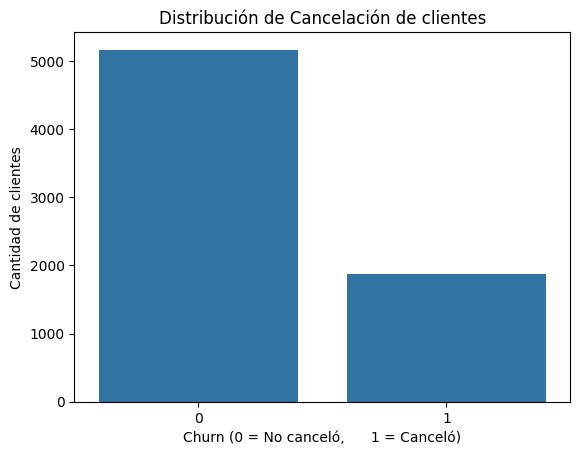

In [123]:
sns.countplot(x="churn", data=df_flattened)

plt.title("Distribución de Cancelación de clientes")
plt.xlabel("Churn (0 = No canceló,      1 = Canceló)")
plt.ylabel("Cantidad de clientes")

plt.show()

Aca vemos los clientes que permanecesn y los que cancelaron

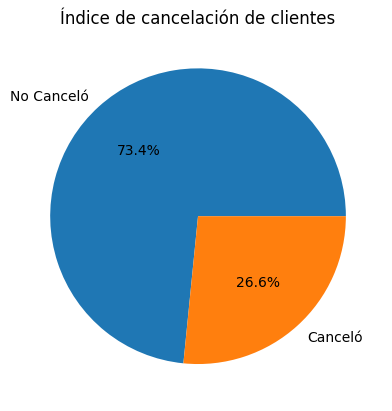

In [124]:
df_flattened["churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["No Canceló", "Canceló"]
)

plt.title("Índice de cancelación de clientes")
plt.ylabel("")
plt.show()

El análisis de la variable churn nos muestra que la mayoría de los clientes permanecen en el servicio. Aproximadamente 73% de los clientes continúan utilizando el servicio, mientras que alrededor del 27% lo han cancelado.
Esto indica que, aunque la mayoría de los clientes se mantienen, existe una proporción significativa de evasión que podría analizarse para identificar los factores que influyen en la cancelación del servicio.

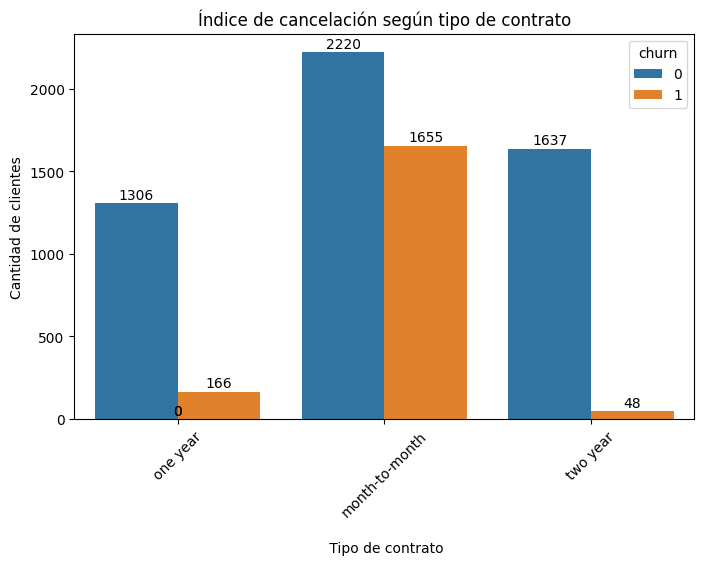

In [125]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="account_contract",
    hue="churn",
    data=df_flattened
)

plt.title("Índice de cancelación según tipo de contrato")
plt.xlabel("\n Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)

# agregar valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 25,int(height),ha="center")

plt.show()

Los clientes con contratos mensuales presentan una mayor proporción de churn en comparación con los clientes con contratos anuales o bianuales, lo que sugiere que la falta de compromiso a largo plazo aumenta la probabilidad de cancelación.

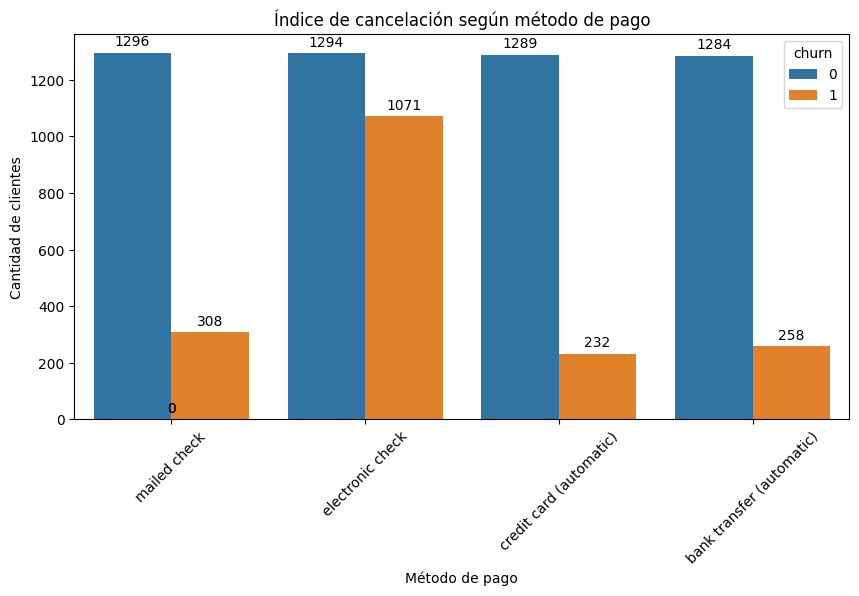

In [126]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    x="account_paymentmethod",
    hue="churn",
    data=df_flattened
)

plt.title("Índice de cancelación según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")

plt.xticks(rotation=45)

# agregar valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 25,int(height),ha="center")

plt.show()

Se observa que los clientes que utilizan cheque electrónico presentan una mayor tasa de churn en comparación con otros métodos de pago.

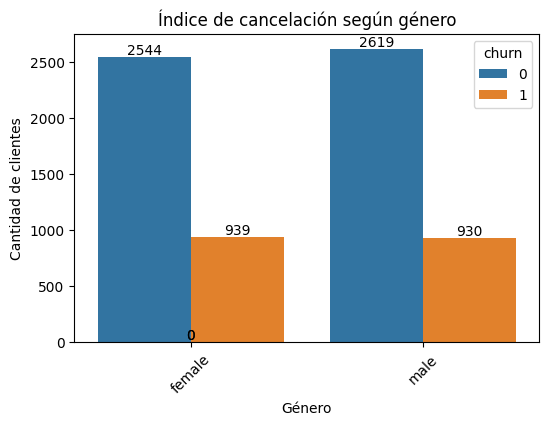

In [127]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="customer_gender",
    hue="churn",
    data=df_flattened
)

plt.title("Índice de cancelación según género")
plt.xlabel("Género")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)

# agregar valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 25,int(height),ha="center")


plt.show()

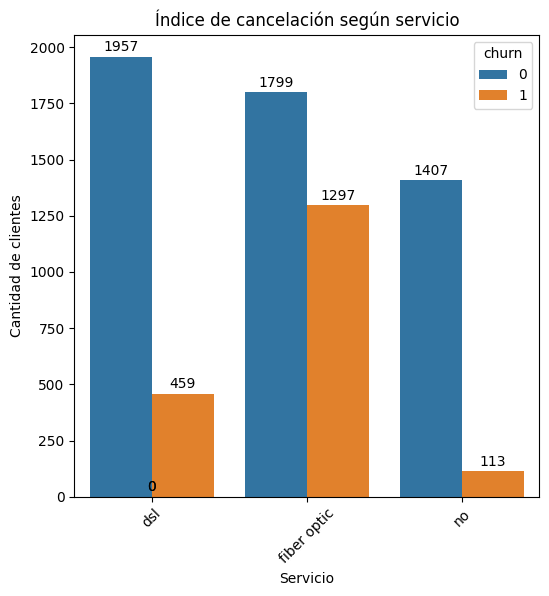

In [128]:
plt.figure(figsize=(6,6))

ax = sns.countplot(
    x="internet_internetservice",
    hue="churn",
    data=df_flattened
)

plt.title("Índice de cancelación según servicio")
plt.xlabel("Servicio")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)

# agregar valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 25,int(height),ha="center")


plt.show()

El análisis del churn según el tipo de servicio de internet muestra diferencias claras entre los grupos. Los clientes con fibra óptica presentan una tasa de cancelación considerablemente mayor en comparación con los usuarios de DSL o aquellos sin servicio de internet (NO). Por otro lado, los clientes sin servicio de internet (NO) presentan la menor tasa de cancelación, lo que sugiere que los usuarios con planes más complejos o costosos podrían ser más propensos a abandonar el servicio.


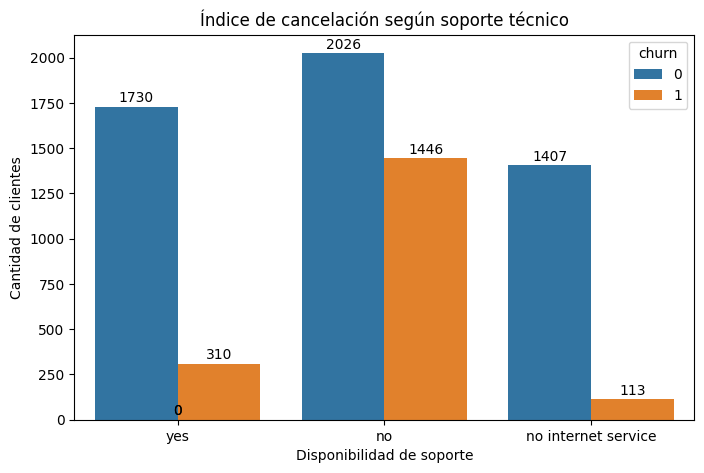

In [129]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="internet_techsupport",
    hue="churn",
    data=df_flattened
)


plt.title("Índice de cancelación según soporte técnico")
plt.xlabel("Disponibilidad de soporte")
plt.ylabel("Cantidad de clientes")

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2, height + 25, int(height), ha="center")

plt.show()





El soporte técnico parece tener una relación significativa con la retención de clientes. Los clientes que cuentan con este servicio presentan una menor probabilidad de cancelar, mientras que aquellos que no tienen acceso al soporte muestran una tasa de churn considerablemente mayor.

Esto sugiere que la disponibilidad de soporte técnico podría ser un factor importante para mejorar la satisfacción del cliente y reducir la cancelación del servicio.

# Conteo de evasion por variables numericas

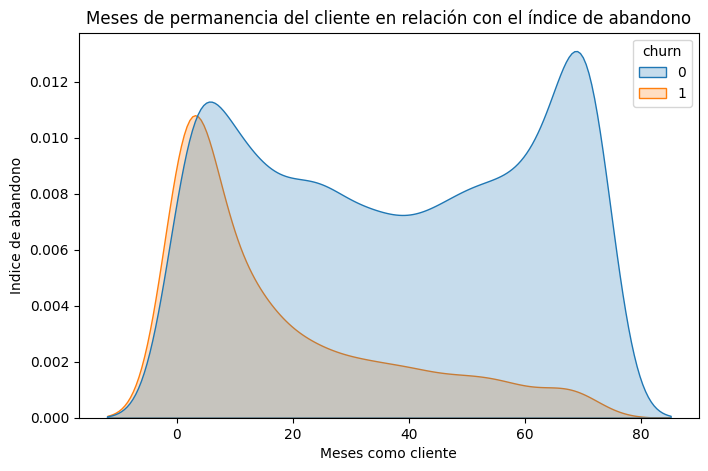

In [130]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_flattened,
    x="customer_tenure",
    hue="churn",
    fill=True
)

plt.title("Meses de permanencia del cliente en relación con el índice de abandono")
plt.xlabel("Meses como cliente")
plt.ylabel("Indice de abandono")

plt.show()

Se observa que la mayor concentración de clientes que cancelaron el servicio se encuentra en los primeros meses de relación con la empresa, especialmente en valores bajos de tenure.

Esto indica que la cancelación ocurre con mayor frecuencia en las primeras etapas del contrato, cuando los clientes aún no han desarrollado una relación prolongada con el servicio.

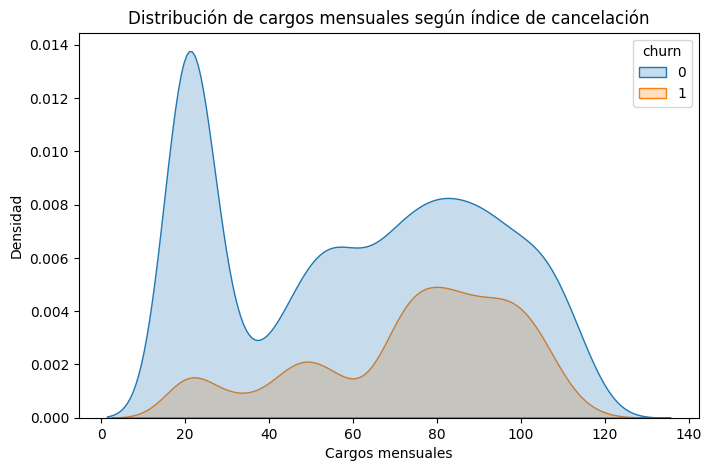

In [134]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_flattened,
    x="account_charges_monthly",
    hue="churn",
    fill=True
)

plt.title("Distribución de cargos mensuales según índice de cancelación")
plt.xlabel("Cargos mensuales")
plt.ylabel("Densidad")


plt.show()

En el grafico se aprecia que los cargos mensuales pueden influir en la evasión de clientes. Aquellos clientes con costos mensuales más altos parecen tener una mayor probabilidad de cancelar el servicio, posiblemente debido a que perciben el servicio como costoso o no encuentran suficiente valor en relación con el precio.

Este resultado indica que el precio del servicio podría ser un factor relevante en la decisión de cancelación, lo que podría motivar estrategias de retención como ajustes en los planes, promociones o mejoras en la propuesta de valor.

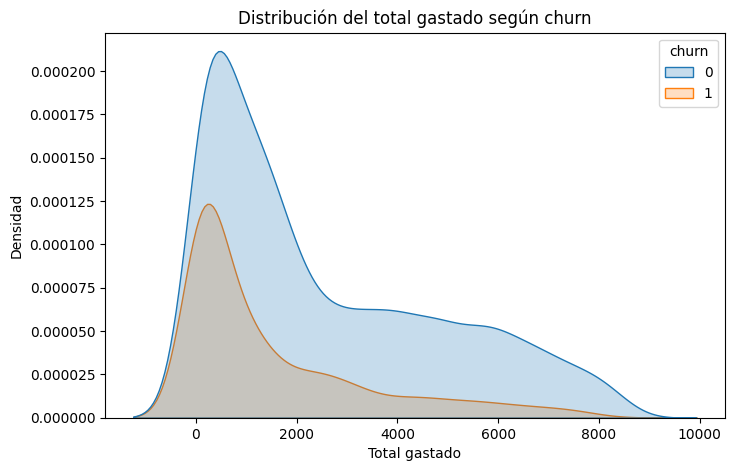

In [135]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_flattened,
    x="account_charges_total",
    hue="churn",
    fill=True
)

plt.title("Distribución del total gastado según churn")
plt.xlabel("Total gastado")
plt.ylabel("Densidad")

plt.show()

Se observa que los clientes que cancelaron el servicio tienden a concentrarse en valores bajos de gasto total. Esto indica que muchos de estos clientes no permanecieron mucho tiempo en la empresa, por lo que no acumularon un gasto elevado. Por otro lado, los clientes que permanecen en el servicio presentan una distribución que se extiende hacia valores más altos de gasto total. Esto sugiere que estos clientes han mantenido una relación más larga con la empresa, acumulando mayores pagos a lo largo del tiempo.

# Analisis de evasión por variables numéricas

 El análisis de las variables numéricas permitió identificar patrones relevantes asociados con la evasión de clientes. A partir de los gráficos de distribución se observa que los clientes que cancelan el servicio tienden a presentar menor antigüedad (tenure) y menor gasto total acumulado, lo que sugiere que la evasión ocurre con mayor frecuencia en las primeras etapas de la relación con la empresa.

Asimismo, se observa que los clientes con cargos mensuales más altos muestran una mayor tendencia a cancelar el servicio. En conjunto, estos resultados indican que factores como el tiempo como cliente y el costo mensual del servicio pueden influir significativamente en la probabilidad de churn.

#📄Informe final

# Introducción

La evasión de clientes, también conocida como churn, representa uno de los principales desafíos para las empresas que ofrecen servicios por suscripción. Cuando un cliente cancela el servicio, la empresa no solo pierde ingresos recurrentes, sino que también debe invertir más recursos para adquirir nuevos clientes.

El objetivo de este análisis es explorar los datos de clientes de una empresa de telecomunicaciones con el fin de identificar patrones asociados con la cancelación del servicio. A través de técnicas de análisis exploratorio de datos (EDA), se busca comprender qué características de los clientes están relacionadas con una mayor probabilidad de churn y generar insights que puedan ayudar a mejorar la retención de clientes.

## Limpieza y Tratamiento de Datos

Antes de realizar el análisis exploratorio, se llevó a cabo un proceso de limpieza y preparación de los datos. En primer lugar, se importó el dataset y se revisó su estructura para identificar valores faltantes, tipos de datos y posibles inconsistencias.

Posteriormente, se eliminaron registros con valores faltantes y se verificó que no existieran duplicados en el conjunto de datos. También se realizó la transformación de algunas variables categóricas, convirtiendo valores como "yes" y "no" en variables binarias para facilitar el análisis.

Además, se ajustaron los tipos de datos de ciertas columnas numéricas y se creó una variable adicional llamada **cuentas_diarias**, que permite analizar el gasto diario aproximado de los clientes a partir de los cargos mensuales.


## Análisis Exploratorio de Datos

Durante el análisis exploratorio se estudiaron tanto variables categóricas como numéricas para identificar patrones relacionados con la evasión de clientes.

En primer lugar, se analizó la distribución general de la variable churn, observando que aproximadamente una cuarta parte de los clientes ha cancelado el servicio.

Posteriormente, se exploró la relación entre churn y distintas variables categóricas como el tipo de contrato, el método de pago, el tipo de servicio de internet y la disponibilidad de soporte técnico. Los resultados mostraron que los clientes con contratos mensuales presentan una mayor tasa de cancelación en comparación con aquellos con contratos de largo plazo. Asimismo, se observó que los usuarios con servicio de fibra óptica y aquellos que no cuentan con soporte técnico presentan mayores niveles de churn.

Finalmente, se analizaron variables numéricas como el tiempo de permanencia del cliente (tenure), los cargos mensuales y el total gastado. Los gráficos de distribución mostraron que los clientes que cancelan el servicio suelen tener menor antigüedad y menor gasto total acumulado, mientras que los clientes con cargos mensuales más elevados presentan una mayor tendencia a cancelar el servicio.


## Conclusiones e Insights

El análisis realizado permitió identificar varios factores asociados con la evasión de clientes. En primer lugar, se observa que los clientes con contratos mensuales presentan una mayor probabilidad de cancelar el servicio en comparación con aquellos con contratos de mayor duración.

Además, el tiempo de permanencia del cliente se muestra como un factor clave, ya que la mayoría de las cancelaciones ocurren durante los primeros meses de relación con la empresa. Esto sugiere que las primeras etapas de la experiencia del cliente son críticas para su retención.

También se identificó que los clientes con cargos mensuales más altos presentan una mayor tendencia a cancelar el servicio, lo que podría indicar que el precio o la percepción de valor del servicio influye en la decisión de abandono.

En conjunto, estos resultados proporcionan información valiosa sobre los perfiles de clientes con mayor riesgo de churn.


## Recomendaciones

A partir de los resultados obtenidos, se pueden proponer algunas estrategias para reducir la evasión de clientes.

En primer lugar, se recomienda implementar estrategias de fidelización dirigidas a clientes nuevos, especialmente durante los primeros meses de servicio, ya que este período presenta el mayor riesgo de cancelación.

También podría ser útil incentivar contratos de mayor duración mediante descuentos o beneficios adicionales, con el fin de reducir la tasa de churn asociada a los contratos mensuales.

Asimismo, mejorar el acceso y la calidad del soporte técnico podría contribuir a aumentar la satisfacción del cliente y reducir la probabilidad de cancelación.

Finalmente, se sugiere revisar la estructura de precios o el valor percibido del servicio, particularmente para los clientes con cargos mensuales más altos, con el objetivo de mejorar la retención y la experiencia del usuario.


# ¡Extra! Análisis de correlación entre variables

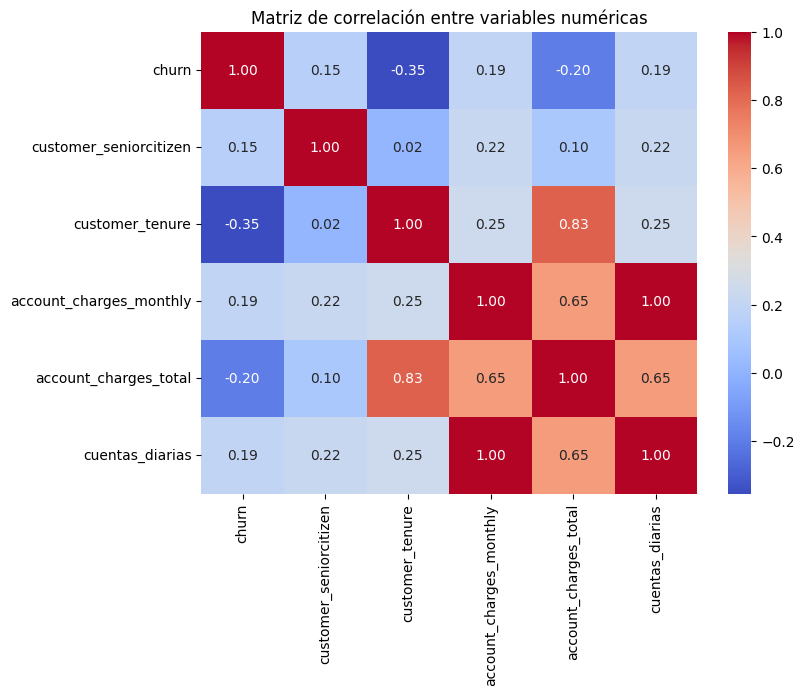

In [138]:
corr = df_flattened.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Matriz de correlación entre variables numéricas")

plt.show()

## Análisis de la matriz de correlación entre variables numéricas

La matriz de correlación permite identificar el grado de relación lineal entre las variables numéricas del dataset. En este caso, se analizaron variables como el tiempo de permanencia del cliente (tenure), los cargos mensuales, el total gastado, la cuenta diaria y el índice de cancelación (churn).

Uno de los resultados más claros es la **alta correlación positiva entre el total gastado (account_charges_total) y el tiempo de permanencia del cliente (customer_tenure)**. Esto es esperable, ya que los clientes que permanecen más tiempo en el servicio acumulan naturalmente un mayor gasto total.

También se observa una **correlación fuerte entre los cargos mensuales y la variable cuentas_diarias**, lo cual es lógico porque la cuenta diaria fue calculada a partir de los cargos mensuales.

En cuanto a la relación con la variable **churn**, las correlaciones con las variables numéricas son relativamente bajas. Esto sugiere que la evasión de clientes no depende únicamente de factores numéricos, sino que también está influenciada por variables categóricas como el tipo de contrato, el servicio de internet o la disponibilidad de soporte técnico.

En conjunto, este análisis confirma que el comportamiento de churn es un fenómeno multifactorial que requiere considerar diferentes características de los clientes para comprender mejor sus causas.


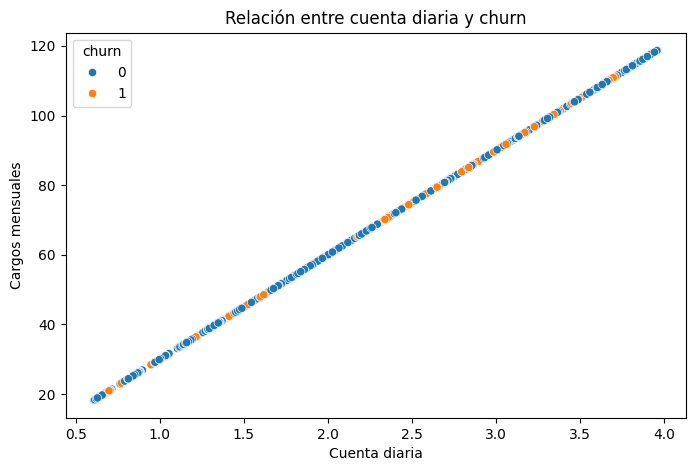

In [139]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_flattened,
    x="cuentas_diarias",
    y="account_charges_monthly",
    hue="churn"
)

plt.title("Relación entre cuenta diaria y churn")
plt.xlabel("Cuenta diaria")
plt.ylabel("Cargos mensuales")

plt.show()

## Análisis de la relación entre cuenta diaria y cargos mensuales según churn

El gráfico de dispersión permite observar la relación entre el gasto diario estimado de los clientes (cuentas_diarias) y los cargos mensuales del servicio, diferenciando entre aquellos que cancelaron el servicio y los que permanecen.

Como era de esperarse, existe una relación directa entre ambas variables, ya que la cuenta diaria fue calculada a partir de los cargos mensuales. Esto se refleja en la tendencia ascendente de los puntos en el gráfico, donde a medida que aumentan los cargos mensuales también aumenta el gasto diario.

En cuanto a la evasión de clientes, se observa que los clientes que cancelaron el servicio tienden a concentrarse en niveles de gasto mensual relativamente más altos. Esto sugiere que los costos del servicio podrían influir en la decisión de cancelar, especialmente cuando los clientes perciben que el precio no corresponde con el valor recibido.

En general, este gráfico refuerza la idea de que el nivel de gasto del cliente puede estar relacionado con el churn, aunque no es el único factor determinante, ya que la evasión también depende de otras variables como el tipo de contrato, la antigüedad del cliente y los servicios contratados.
